In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb

#machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv('churn_data.csv')

In [3]:
data.head(10)

,CustomerID,Gender,Age,Tenure,Balance,Products,HasCreditCard,IsActiveMember,EstimatedSalary,Geography,Churn
0,CUST100000,F,29,67,42290.135182,2,Y,No,117422.959315,Nigeria,0
1,CUST100001,male,64,62,8572.456413,1,Y,No,69733.588343,Nigeria,1
2,CUST100002,M,57,109,73354.838511,1,No,Yes,105949.108279,Ghana,0
3,CUST100003,male,53,39,34499.100740,3,N,Yes,95555.653349,Nigeria,0
4,CUST100004,male,32,37,32910.130745,3,Y,Yes,54565.383506,Nigeria,1
5,CUST100005,Female,45,119,41938.682639,4,No,Yes,51892.344679,Ghana,0
6,CUST100006,M,69,114,55444.734507,2,Yes,No,86597.269123,Ghana,1
7,CUST100007,M,66,86,48854.591784,2,N,No,47459.864269,Nigeria,0
8,CUST100008,M,62,8,60961.338494,2,Y,No,139551.037141,Kenya,0
9,CUST100009,male,35,81,23210.212669,1,No,Yes,153797.875058,Kenya,1


In [4]:
data.tail(10)

,CustomerID,Gender,Age,Tenure,Balance,Products,HasCreditCard,IsActiveMember,EstimatedSalary,Geography,Churn
5040,CUST103599,Female,50,111,27498.073460,2,Yes,Yes,7.728909e+04,Kenya,0
5041,CUST104121,F,44,105,65513.505992,1,N,No,1.467188e+06,Kenya,0
5042,CUST100029,M,44,16,31379.965767,3,N,Yes,1.454164e+05,Nigeria,0
5043,CUST100065,F,48,102,15215.896957,1,N,Yes,1.086203e+05,Ghana,0
5044,CUST100838,Male,63,117,82779.210552,3,Y,Yes,6.954963e+04,Nigeria,1
5045,CUST103906,male,54,1,26375.976537,1,Yes,No,6.285725e+04,Nigeria,0
5046,CUST103773,female,46,26,39941.806999,2,Y,No,1.418710e+05,Kenya,1
5047,CUST104635,female,35,97,63587.627460,1,Y,Yes,1.456833e+05,Kenya,0
5048,CUST103161,M,32,80,68308.059410,2,Y,No,3.043359e+04,Nigeria,0
5049,CUST102659,Female,23,115,72413.714128,3,Yes,Yes,6.248814e+04,Kenya,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5050 non-null   object 
 1   Gender           5050 non-null   object 
 2   Age              5050 non-null   int64  
 3   Tenure           5050 non-null   int64  
 4   Balance          4745 non-null   float64
 5   Products         5050 non-null   int64  
 6   HasCreditCard    5050 non-null   object 
 7   IsActiveMember   5050 non-null   object 
 8   EstimatedSalary  5050 non-null   float64
 9   Geography        5050 non-null   object 
 10  Churn            5050 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 434.1+ KB


In [6]:
blanks =data.isna().sum()

In [7]:
blanks

CustomerID           0
Gender               0
Age                  0
Tenure               0
Balance            305
Products             0
HasCreditCard        0
IsActiveMember       0
EstimatedSalary      0
Geography            0
Churn                0
dtype: int64

In [8]:
data['Balance'] = data['Balance'].fillna(data['Balance'].mean())

In [9]:
data.duplicated().any()

True

In [10]:
data.duplicated().sum()

50

In [11]:
data = data.drop_duplicates()

In [12]:
data = data.drop('CustomerID', axis = 1)

In [13]:
data.describe()

,Age,Tenure,Balance,Products,EstimatedSalary,Churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.00000
mean,43.488400,59.990600,50004.032619,1.778600,1.095248e+05,0.20000
std,14.857228,33.963575,19411.155677,0.902521,1.057316e+05,0.40004
min,18.000000,1.000000,-28448.005032,1.000000,-5.870846e+04,0.00000
25%,31.000000,31.000000,37827.844679,1.000000,7.305927e+04,0.00000
50%,43.000000,61.000000,50023.717845,2.000000,1.009350e+05,0.00000
75%,56.000000,89.000000,62414.247186,2.000000,1.277434e+05,0.00000
max,69.000000,119.000000,117555.364826,4.000000,1.869504e+06,1.00000


In [14]:
data['Gender'] = data['Gender'].replace({
    'F': 'Female',
    'female': 'Female'
})

In [15]:
data['Gender'] = data['Gender'].replace({
    'M': 'Male',
    'male': 'Male'
})

In [16]:
data['HasCreditCard'] = data['HasCreditCard'].replace('Y','Yes')

In [17]:
data['HasCreditCard'] = data['HasCreditCard'].replace('N', 'No')

In [18]:
data[['Balance', 'EstimatedSalary']] = data[['Balance', 'EstimatedSalary']].abs()

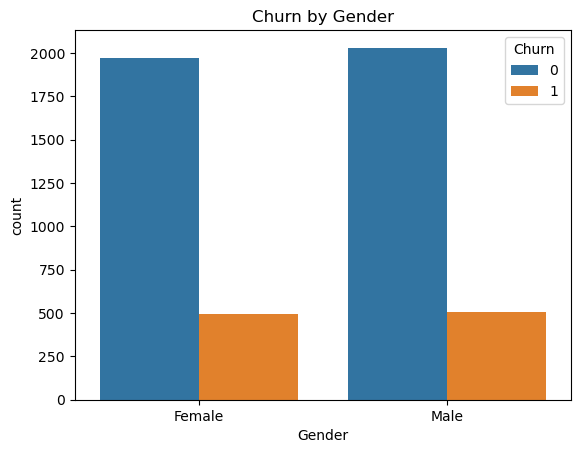

In [30]:
sns.countplot(x = 'Gender', hue = 'Churn', data = data)
plt.title('Churn by Gender')
plt.savefig('gender.png')
plt.show()

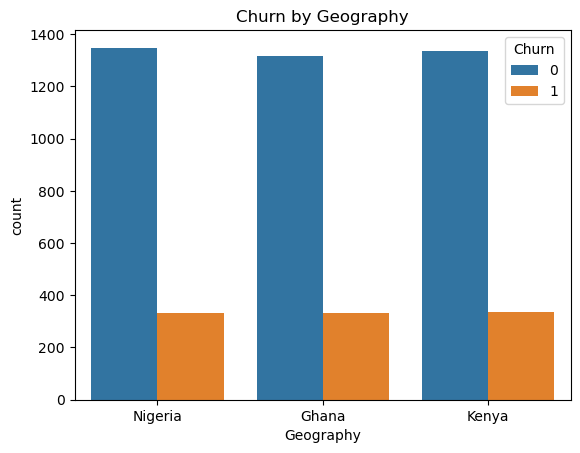

In [31]:
sns.countplot(x = 'Geography', hue = 'Churn', data = data)
plt.title('Churn by Geography')
plt.savefig('geography.png')
plt.show()

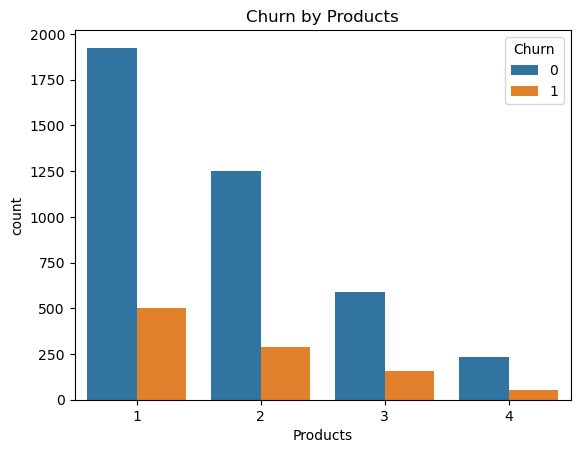

In [21]:
sns.countplot(x = 'Products', hue = 'Churn', data = data)
plt.title('Churn by Products')
plt.show()

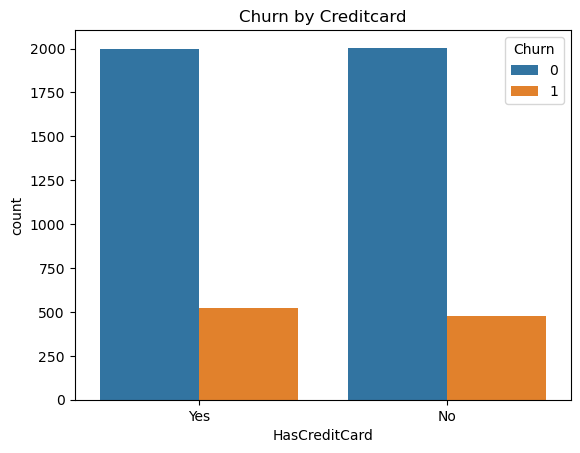

In [22]:
sns.countplot(x = 'HasCreditCard', hue = 'Churn', data = data)
plt.title('Churn by Creditcard')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

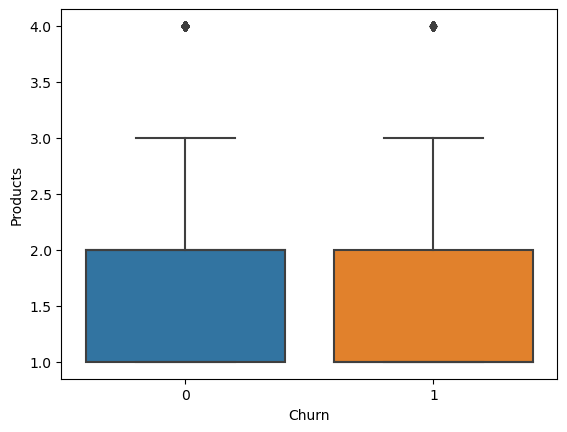

In [23]:
sns.boxplot(x='Churn', y= 'Products', data = data)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

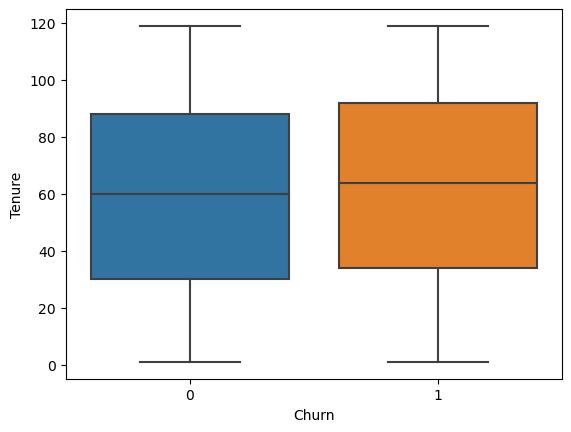

In [24]:
sns.boxplot(x='Churn', y= 'Tenure', data = data)
plt.savefig('myplot.png')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

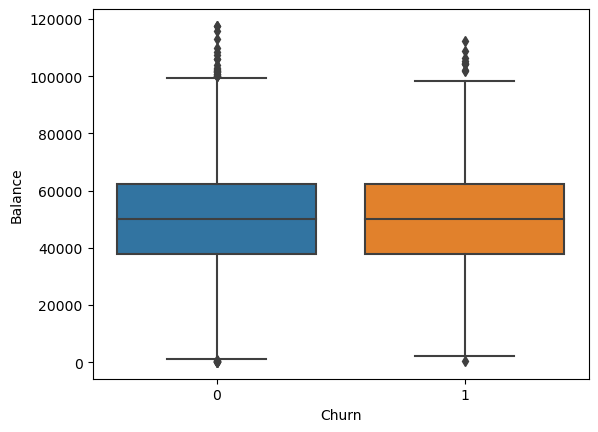

In [25]:
sns.boxplot(x='Churn', y= 'Balance', data = data)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

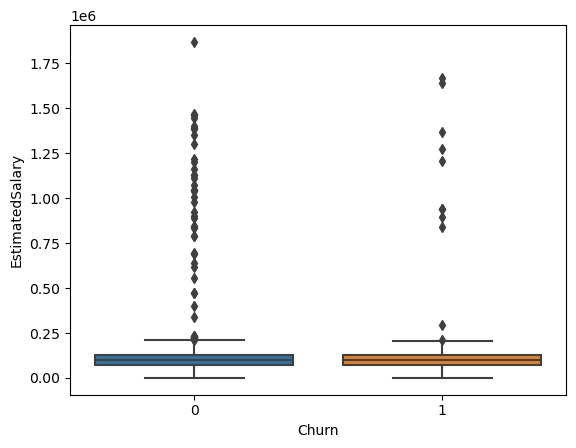

In [26]:
sns.boxplot(x='Churn', y= 'EstimatedSalary', data = data)
plt.show

In [27]:
corr = data.corr(numeric_only = True)

<Axes: >

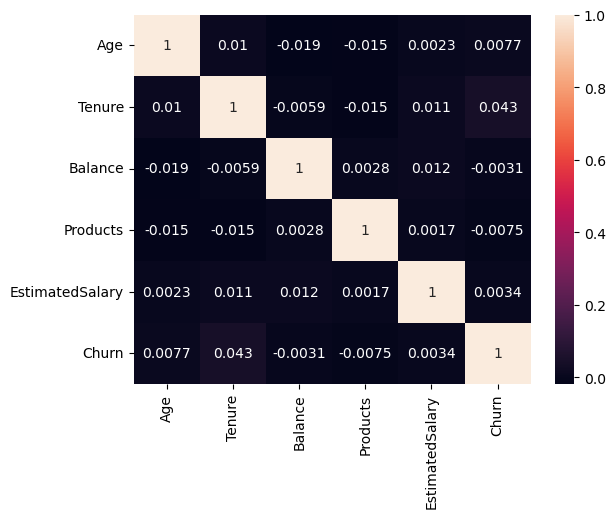

In [28]:
sns.heatmap(corr, annot = True)


In [29]:
data['Geography'] = le.fit_transform(data['Geography'])
data['Gender'] = le.fit_transform(data['Gender'])
data['HasCreditCard'] = le.fit_transform(data['HasCreditCard'])
data['IsActiveMember'] = le.fit_transform(data['IsActiveMember'])

NameError: name 'le' is not defined

In [ ]:
x =data.drop('Churn', axis = 1)
y = data['Churn']

In [ ]:
x

In [ ]:
y

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
x,y, test_size =0.2, random_state =42)

In [ ]:
model = RandomForestClassifier()

In [ ]:
model.fit(x_train, y_train)

In [ ]:
jb.dump(model, "Churn_data.joblib")

In [ ]:
predictions = model.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_test, predictions)

In [ ]:
accuracy

In [ ]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True)
plt.savefig('confusionmatrix.png')
plt.show()

In [ ]:
predictions

In [ ]:
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=x.columns)
feature_importance.sort_values().plot(kind="barh")
plt.show()

In [ ]:
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=x.columns)
feature_importance.sort_values().plot(kind="pie")
plt.show()